In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
DATA_DIR = Path(
    "/kaggle/input/datasets/notjustauser/smard-2022-2024"
)
list(DATA_DIR.iterdir())

[PosixPath('/kaggle/input/datasets/notjustauser/smard-2022-2024/Forecasted_consumption_202208312015_202409012015_Hour.csv'),
 PosixPath('/kaggle/input/datasets/notjustauser/smard-2022-2024/Actual_consumption_202208312015_202409012015_Hour.csv'),
 PosixPath('/kaggle/input/datasets/notjustauser/smard-2022-2024/Day-ahead_prices_202208312015_202409012015_Hour.csv')]

In [3]:
def inspect_csv(path):
    df = pd.read_csv(
        path,
        sep=None,
        engine="python"
    )

    print("=" * 80)
    print("FILE:", path)
    print("Shape:", df.shape)

    print("\nFIRST 5 ROWS")
    display(df.head())

    print("\nCOLUMNS")
    print(df.columns.tolist())

    print("\nDTYPES")
    print(df.dtypes)

    print("\nMISSING VALUES")
    print(df.isna().sum())

    print("\nDUPLICATE ROWS")
    print(df.duplicated().sum())

    return df

In [4]:
files = list(DATA_DIR.glob("*.csv"))

files

[PosixPath('/kaggle/input/datasets/notjustauser/smard-2022-2024/Forecasted_consumption_202208312015_202409012015_Hour.csv'),
 PosixPath('/kaggle/input/datasets/notjustauser/smard-2022-2024/Actual_consumption_202208312015_202409012015_Hour.csv'),
 PosixPath('/kaggle/input/datasets/notjustauser/smard-2022-2024/Day-ahead_prices_202208312015_202409012015_Hour.csv')]

In [5]:
price_raw = inspect_csv(
    DATA_DIR / "Day-ahead_prices_202208312015_202409012015_Hour.csv"
)

FILE: /kaggle/input/datasets/notjustauser/smard-2022-2024/Day-ahead_prices_202208312015_202409012015_Hour.csv
Shape: (17568, 19)

FIRST 5 ROWS


,﻿Start date,End date,Germany/Luxembourg [€/MWh] Calculated resolutions,∅ DE/LU neighbours [€/MWh] Calculated resolutions,Belgium [€/MWh] Calculated resolutions,Denmark 1 [€/MWh] Calculated resolutions,Denmark 2 [€/MWh] Calculated resolutions,France [€/MWh] Calculated resolutions,Netherlands [€/MWh] Calculated resolutions,Norway 2 [€/MWh] Calculated resolutions,Austria [€/MWh] Calculated resolutions,Poland [€/MWh] Calculated resolutions,Sweden 4 [€/MWh] Calculated resolutions,Switzerland [€/MWh] Calculated resolutions,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions
0,"Aug 31, 2022 9:00 PM","Aug 31, 2022 10:00 PM",677.26,650.81,624.0,677.26,677.26,706.07,654.91,652.57,665.96,437.98,661.01,709.92,691.94,-,706.07,706.07,802.69
1,"Aug 31, 2022 10:00 PM","Aug 31, 2022 11:00 PM",563.52,560.64,504.5,563.52,563.52,667.21,499.90,577.47,585.08,380.92,550.00,679.91,595.05,-,639.30,627.76,729.14
2,"Aug 31, 2022 11:00 PM","Sep 1, 2022 12:00 AM",532.51,489.37,397.4,532.51,532.51,601.90,478.61,543.26,550.02,257.08,309.97,639.95,539.87,-,601.90,550.70,545.23
3,"Sep 1, 2022 12:00 AM","Sep 1, 2022 1:00 AM",490.77,450.22,331.7,490.77,490.77,571.39,426.40,505.43,508.74,248.17,309.99,569.92,499.10,-,571.39,511.66,505.47
4,"Sep 1, 2022 1:00 AM","Sep 1, 2022 2:00 AM",484.36,446.89,389.4,484.36,484.36,532.14,445.96,498.83,495.02,246.59,309.93,539.91,489.33,-,540.00,496.72,493.08



COLUMNS
['\ufeffStart date', 'End date', 'Germany/Luxembourg [€/MWh] Calculated resolutions', '∅ DE/LU neighbours [€/MWh] Calculated resolutions', 'Belgium [€/MWh] Calculated resolutions', 'Denmark 1 [€/MWh] Calculated resolutions', 'Denmark 2 [€/MWh] Calculated resolutions', 'France [€/MWh] Calculated resolutions', 'Netherlands [€/MWh] Calculated resolutions', 'Norway 2 [€/MWh] Calculated resolutions', 'Austria [€/MWh] Calculated resolutions', 'Poland [€/MWh] Calculated resolutions', 'Sweden 4 [€/MWh] Calculated resolutions', 'Switzerland [€/MWh] Calculated resolutions', 'Czech Republic [€/MWh] Calculated resolutions', 'DE/AT/LU [€/MWh] Calculated resolutions', 'Northern Italy [€/MWh] Calculated resolutions', 'Slovenia [€/MWh] Calculated resolutions', 'Hungary [€/MWh] Calculated resolutions']

DTYPES
﻿Start date                                           object
End date                                              object
Germany/Luxembourg [€/MWh] Calculated resolutions    float64
∅ D

In [6]:
actual_raw = inspect_csv(
    DATA_DIR / "Actual_consumption_202208312015_202409012015_Hour.csv"
)

FILE: /kaggle/input/datasets/notjustauser/smard-2022-2024/Actual_consumption_202208312015_202409012015_Hour.csv
Shape: (17568, 6)

FIRST 5 ROWS


,﻿Start date,End date,grid load [MWh] Calculated resolutions,Grid load incl. hydro pumped storage [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
0,"Aug 31, 2022 9:00 PM","Aug 31, 2022 10:00 PM","54,065.25","54,626.25",561.00,"42,461.75"
1,"Aug 31, 2022 10:00 PM","Aug 31, 2022 11:00 PM","50,545.00","51,179.00",634.00,"37,582.50"
2,"Aug 31, 2022 11:00 PM","Sep 1, 2022 12:00 AM","46,610.50","47,159.00",548.50,"33,253.50"
3,"Sep 1, 2022 12:00 AM","Sep 1, 2022 1:00 AM","43,779.50","45,140.50","1,361.00","30,988.50"
4,"Sep 1, 2022 1:00 AM","Sep 1, 2022 2:00 AM","42,271.75","45,145.00","2,873.25","30,840.75"



COLUMNS
['\ufeffStart date', 'End date', 'grid load [MWh] Calculated resolutions', 'Grid load incl. hydro pumped storage [MWh] Calculated resolutions', 'Hydro pumped storage [MWh] Calculated resolutions', 'Residual load [MWh] Calculated resolutions']

DTYPES
﻿Start date                                                          object
End date                                                             object
grid load [MWh] Calculated resolutions                               object
Grid load incl. hydro pumped storage [MWh] Calculated resolutions    object
Hydro pumped storage [MWh] Calculated resolutions                    object
Residual load [MWh] Calculated resolutions                           object
dtype: object

MISSING VALUES
﻿Start date                                                          0
End date                                                             0
grid load [MWh] Calculated resolutions                               0
Grid load incl. hydro pumped storage [MWh

In [7]:
forecasted_raw = inspect_csv(
    DATA_DIR / "Forecasted_consumption_202208312015_202409012015_Hour.csv"
)

FILE: /kaggle/input/datasets/notjustauser/smard-2022-2024/Forecasted_consumption_202208312015_202409012015_Hour.csv
Shape: (17568, 4)

FIRST 5 ROWS


,﻿Start date,End date,grid load [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
0,"Aug 31, 2022 9:00 PM","Aug 31, 2022 10:00 PM","54,673.50","42,935.00"
1,"Aug 31, 2022 10:00 PM","Aug 31, 2022 11:00 PM","50,893.75","38,777.75"
2,"Aug 31, 2022 11:00 PM","Sep 1, 2022 12:00 AM","47,281.75","35,460.50"
3,"Sep 1, 2022 12:00 AM","Sep 1, 2022 1:00 AM","45,334.25","34,734.75"
4,"Sep 1, 2022 1:00 AM","Sep 1, 2022 2:00 AM","43,953.25","34,378.00"



COLUMNS
['\ufeffStart date', 'End date', 'grid load [MWh] Calculated resolutions', 'Residual load [MWh] Calculated resolutions']

DTYPES
﻿Start date                                   object
End date                                      object
grid load [MWh] Calculated resolutions        object
Residual load [MWh] Calculated resolutions    object
dtype: object

MISSING VALUES
﻿Start date                                   0
End date                                      0
grid load [MWh] Calculated resolutions        0
Residual load [MWh] Calculated resolutions    0
dtype: int64

DUPLICATE ROWS
0


In [8]:
#Removing the BOM(ufeff) character
for df in [price_raw, actual_raw, forecasted_raw]:
    df.columns = df.columns.str.replace("\ufeff", "", regex=False).str.strip()

In [9]:
PRICE_SOURCE_COLUMN = (
    "Germany/Luxembourg [€/MWh] Calculated resolutions"
)

LOAD_SOURCE_COLUMN = (
    "grid load [MWh] Calculated resolutions"
)

required_columns = {
    "price_raw": {
        "Start date",
        "End date",
        PRICE_SOURCE_COLUMN,
    },
    "actual_raw": {
        "Start date",
        "End date",
        LOAD_SOURCE_COLUMN,
    },
    "forecasted_raw": {
        "Start date",
        "End date",
        LOAD_SOURCE_COLUMN,
    },
}

source_frames = {
    "price_raw": price_raw,
    "actual_raw": actual_raw,
    "forecasted_raw": forecasted_raw,
}

for frame_name, required in required_columns.items():
    frame = source_frames[frame_name]

    missing = required.difference(frame.columns)

    if missing:
        raise KeyError(
            f"{frame_name} is missing required columns: "
            f"{sorted(missing)}"
        )

    print(
        f"{frame_name}: schema validated, "
        f"{len(frame):,} rows"
    )

price_raw: schema validated, 17,568 rows
actual_raw: schema validated, 17,568 rows
forecasted_raw: schema validated, 17,568 rows


In [10]:
print(repr(price_raw["Start date"].iloc[0]))
print(repr(price_raw["End date"].iloc[0]))

'Aug 31, 2022 9:00 PM'
'Aug 31, 2022 10:00 PM'


In [11]:
print(price_raw["Start date"].dtype)
print(actual_raw["Start date"].dtype)
print(forecasted_raw["Start date"].dtype)

object
object
object


In [12]:
date_format = "%b %d, %Y %I:%M %p"

for df in [price_raw, actual_raw, forecasted_raw]:
    df["Start date"] = pd.to_datetime(
        df["Start date"].astype(str).str.strip(),
        format=date_format,
        errors="raise"
    )

    df["End date"] = pd.to_datetime(
        df["End date"].astype(str).str.strip(),
        format=date_format,
        errors="raise"
    )

In [13]:
print(price_raw[["Start date", "End date"]].dtypes)
print(actual_raw[["Start date", "End date"]].dtypes)
print(forecasted_raw[["Start date", "End date"]].dtypes)

Start date    datetime64[ns]
End date      datetime64[ns]
dtype: object
Start date    datetime64[ns]
End date      datetime64[ns]
dtype: object
Start date    datetime64[ns]
End date      datetime64[ns]
dtype: object


In [14]:
def add_utc_timestamp(df):
    """
    Interpret naive SMARD timestamps as German local time and convert
    them into a continuous UTC timeline.
    """
    if not pd.api.types.is_datetime64_any_dtype(
        df["Start date"]
    ):
        raise TypeError(
            "'Start date' must be converted to datetime "
            "before timezone localization."
        )

    # Stable sorting preserves the original order of the two repeated
    # autumn DST hours, which ambiguous='infer' uses for disambiguation.
    result = (
        df
        .sort_values(
            "Start date",
            kind="stable",
        )
        .copy()
    )

    result["timestamp"] = (
        result["Start date"]
        .dt.tz_localize(
            "Europe/Berlin",
            ambiguous="infer",
            nonexistent="raise",
        )
        .dt.tz_convert("UTC")
    )

    if result["timestamp"].isna().any():
        raise ValueError(
            "UTC conversion produced missing timestamps."
        )

    return result


price_raw = add_utc_timestamp(price_raw)
actual_raw = add_utc_timestamp(actual_raw)
forecasted_raw = add_utc_timestamp(forecasted_raw)

In [15]:
price = price_raw[
    [
        "timestamp",
        "Germany/Luxembourg [€/MWh] Calculated resolutions"
    ]
].copy()

price = price.rename(
    columns={
        "Germany/Luxembourg [€/MWh] Calculated resolutions":
        "price_eur_mwh"
    }
)

In [16]:
actual_load = actual_raw[
    [
        "timestamp",
        "grid load [MWh] Calculated resolutions"
    ]
].copy()

actual_load = actual_load.rename(
    columns={
        "grid load [MWh] Calculated resolutions":
        "load_actual_mwh"
    }
)

In [17]:
forecasted_load = forecasted_raw[
    [
        "timestamp",
        "grid load [MWh] Calculated resolutions"
    ]
].copy()

forecasted_load = forecasted_load.rename(
    columns={
        "grid load [MWh] Calculated resolutions":
        "load_forecast_mwh"
    }
)

In [18]:
price = price.set_index("timestamp").sort_index()
actual_load = actual_load.set_index("timestamp").sort_index()
forecasted_load = forecasted_load.set_index("timestamp").sort_index()

In [19]:
data = (
    price
    .join(actual_load, how="inner")
    .join(forecasted_load, how="inner")
    .sort_index()
)

In [20]:
print(
    "Negative prices:",
    (data["price_eur_mwh"] < 0).sum()
)

print(
    "Zero prices:",
    (data["price_eur_mwh"] == 0).sum()
)


Negative prices: 708
Zero prices: 73


In [21]:
print(
    data["price_eur_mwh"]
    .sort_values()
    .head(10)
)

print(
    data["price_eur_mwh"]
    .sort_values(ascending=False)
    .head(10)
)

timestamp
2023-07-02 12:00:00+00:00   -500.00
2023-07-02 13:00:00+00:00   -399.00
2023-07-02 11:00:00+00:00   -266.92
2023-07-02 10:00:00+00:00   -167.96
2024-05-12 11:00:00+00:00   -135.45
2024-05-12 12:00:00+00:00   -132.85
2023-05-28 12:00:00+00:00   -129.96
2023-05-28 11:00:00+00:00   -129.91
2023-07-02 14:00:00+00:00   -124.21
2024-05-01 12:00:00+00:00   -120.07
Name: price_eur_mwh, dtype: float64
timestamp
2022-09-01 17:00:00+00:00    729.90
2022-09-01 18:00:00+00:00    702.09
2022-09-01 16:00:00+00:00    686.23
2022-08-31 19:00:00+00:00    677.26
2022-09-01 05:00:00+00:00    669.21
2022-09-01 06:00:00+00:00    665.46
2022-12-13 16:00:00+00:00    665.01
2022-09-01 04:00:00+00:00    644.71
2022-09-01 19:00:00+00:00    640.72
2022-09-28 17:00:00+00:00    640.42
Name: price_eur_mwh, dtype: float64


In [22]:
print(data[["load_actual_mwh", "load_forecast_mwh"]].dtypes)
print(data[["load_actual_mwh", "load_forecast_mwh"]].head())

load_actual_mwh      object
load_forecast_mwh    object
dtype: object
                          load_actual_mwh load_forecast_mwh
timestamp                                                  
2022-08-31 19:00:00+00:00       54,065.25         54,673.50
2022-08-31 20:00:00+00:00       50,545.00         50,893.75
2022-08-31 21:00:00+00:00       46,610.50         47,281.75
2022-08-31 22:00:00+00:00       43,779.50         45,334.25
2022-08-31 23:00:00+00:00       42,271.75         43,953.25


In [23]:
def parse_smard_numeric(
    series,
    column_name,
    allow_missing=False,
):
    """
    Convert SMARD numeric values such as '52,143.25' to float.

    Only known missing markers are converted to NaN. Any other
    unexpected token raises an error.
    """
    cleaned = (
        series
        .astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .replace(
            {
                "-": pd.NA,
                "": pd.NA,
            }
        )
    )

    numeric = pd.to_numeric(
        cleaned,
        errors="coerce",
    )

    # Values that were present but could not be parsed.
    invalid_mask = (
        cleaned.notna()
        & numeric.isna()
    )

    if invalid_mask.any():
        invalid_examples = (
            cleaned.loc[invalid_mask]
            .drop_duplicates()
            .head(10)
            .tolist()
        )

        raise ValueError(
            f"Unexpected numeric values in {column_name}: "
            f"{invalid_examples}"
        )

    if not allow_missing and numeric.isna().any():
        raise ValueError(
            f"{column_name} contains "
            f"{int(numeric.isna().sum())} missing values."
        )

    return numeric.astype("float64")


# The price is already float in the current export, but applying the
# same parser makes the pipeline safer against future source changes.
data["price_eur_mwh"] = parse_smard_numeric(
    data["price_eur_mwh"],
    column_name="price_eur_mwh",
    allow_missing=False,
)

data["load_actual_mwh"] = parse_smard_numeric(
    data["load_actual_mwh"],
    column_name="load_actual_mwh",
    allow_missing=False,
)

data["load_forecast_mwh"] = parse_smard_numeric(
    data["load_forecast_mwh"],
    column_name="load_forecast_mwh",
    allow_missing=True,
)

print(data.dtypes)
print("\nMissing values after numeric conversion:")
print(data.isna().sum())

price_eur_mwh        float64
load_actual_mwh      float64
load_forecast_mwh    float64
dtype: object

Missing values after numeric conversion:
price_eur_mwh         0
load_actual_mwh       0
load_forecast_mwh    97
dtype: int64


In [24]:
EXPECTED_CLEAN_COLUMNS = [
    "price_eur_mwh",
    "load_actual_mwh",
    "load_forecast_mwh",
]

EXPECTED_HISTORICAL_FORECAST_NANS = 97


def validate_clean_dataset(
    frame,
    expected_forecast_nans=None,
):
    errors = []

    # ------------------------------------------------------------
    # Column validation
    # ------------------------------------------------------------

    if list(frame.columns) != EXPECTED_CLEAN_COLUMNS:
        errors.append(
            "Unexpected column schema. "
            f"Expected {EXPECTED_CLEAN_COLUMNS}, "
            f"found {list(frame.columns)}."
        )

    for column in EXPECTED_CLEAN_COLUMNS:
        if column in frame.columns:
            if not pd.api.types.is_numeric_dtype(
                frame[column]
            ):
                errors.append(
                    f"{column} is not numeric."
                )

            non_missing = frame[column].dropna()

            if np.isinf(non_missing.to_numpy()).any():
                errors.append(
                    f"{column} contains infinite values."
                )

    # ------------------------------------------------------------
    # Timestamp validation
    # ------------------------------------------------------------

    if not isinstance(frame.index, pd.DatetimeIndex):
        errors.append(
            "Dataset index is not a DatetimeIndex."
        )

    else:
        if frame.index.tz is None:
            errors.append(
                "Timestamp index is timezone-naive."
            )

        elif str(frame.index.tz) != "UTC":
            errors.append(
                f"Expected UTC index, found {frame.index.tz}."
            )

        if not frame.index.is_monotonic_increasing:
            errors.append(
                "Timestamp index is not sorted."
            )

        duplicate_count = int(
            frame.index.duplicated().sum()
        )

        if duplicate_count:
            errors.append(
                f"Found {duplicate_count} duplicate timestamps."
            )

        timestamp_differences = (
            frame.index
            .to_series()
            .diff()
            .dropna()
        )

        non_hourly_gaps = timestamp_differences[
            timestamp_differences
            != pd.Timedelta(hours=1)
        ]

        if not non_hourly_gaps.empty:
            errors.append(
                f"Found {len(non_hourly_gaps)} "
                "non-hourly timestamp gaps."
            )

    # ------------------------------------------------------------
    # Missing-value validation
    # ------------------------------------------------------------

    price_missing = int(
        frame["price_eur_mwh"].isna().sum()
    )

    actual_load_missing = int(
        frame["load_actual_mwh"].isna().sum()
    )

    forecast_load_missing = int(
        frame["load_forecast_mwh"].isna().sum()
    )

    if price_missing:
        errors.append(
            f"Target price contains {price_missing} missing values."
        )

    if actual_load_missing:
        errors.append(
            "Actual load contains "
            f"{actual_load_missing} missing values."
        )

    if (
        expected_forecast_nans is not None
        and forecast_load_missing
        != expected_forecast_nans
    ):
        errors.append(
            "Forecast-load missing count changed: "
            f"expected {expected_forecast_nans}, "
            f"found {forecast_load_missing}."
        )

    # ------------------------------------------------------------
    # Confirm that the inner join did not remove timestamps
    # ------------------------------------------------------------

    for source_name, source_frame in {
        "price": price,
        "actual_load": actual_load,
        "forecasted_load": forecasted_load,
    }.items():
        if not source_frame.index.equals(frame.index):
            errors.append(
                f"{source_name} timestamps do not exactly match "
                "the merged dataset."
            )

    if errors:
        raise ValueError(
            "Clean dataset validation failed:\n- "
            + "\n- ".join(errors)
        )

    return {
        "rows": len(frame),
        "start_utc": frame.index.min(),
        "end_utc": frame.index.max(),
        "duplicate_timestamps": int(
            frame.index.duplicated().sum()
        ),
        "non_hourly_gaps": 0,
        "missing_price": price_missing,
        "missing_actual_load": actual_load_missing,
        "missing_forecast_load": (
            forecast_load_missing
        ),
        "negative_prices": int(
            (frame["price_eur_mwh"] < 0).sum()
        ),
        "zero_prices": int(
            (frame["price_eur_mwh"] == 0).sum()
        ),
    }


validation_report = validate_clean_dataset(
    data,
    expected_forecast_nans=(
        EXPECTED_HISTORICAL_FORECAST_NANS
    ),
)

display(
    pd.Series(
        validation_report,
        name="Notebook 01 validation",
    )
)

rows                                         17568
start_utc                2022-08-31 19:00:00+00:00
end_utc                  2024-09-01 18:00:00+00:00
duplicate_timestamps                             0
non_hourly_gaps                                  0
missing_price                                    0
missing_actual_load                              0
missing_forecast_load                           97
negative_prices                                708
zero_prices                                     73
Name: Notebook 01 validation, dtype: object

In [25]:
forecast_missing = (
    data["load_forecast_mwh"].isna()
)

run_groups = (
    forecast_missing
    != forecast_missing.shift()
).cumsum()

missing_runs = (
    data.loc[forecast_missing]
    .groupby(run_groups[forecast_missing])
    .size()
)

missing_run_distribution = (
    missing_runs
    .value_counts()
    .sort_index()
    .rename_axis("consecutive_missing_hours")
    .rename("number_of_runs")
)

print(
    "Total missing forecast-load observations:",
    int(forecast_missing.sum()),
)

print(
    "Largest missing run:",
    int(missing_runs.max()),
    "hours",
)

display(
    missing_run_distribution.to_frame()
)

expected_run_distribution = {
    1: 1,
    24: 2,
    48: 1,
}

actual_run_distribution = {
    int(run_length): int(run_count)
    for run_length, run_count
    in missing_run_distribution.items()
}

if actual_run_distribution != expected_run_distribution:
    raise ValueError(
        "Historical forecast-load gap structure changed. "
        f"Expected {expected_run_distribution}, "
        f"found {actual_run_distribution}."
    )

Total missing forecast-load observations: 97
Largest missing run: 48 hours


,number_of_runs
consecutive_missing_hours,
1,1
24,2
48,1


In [26]:
load_mae = (
    data["load_actual_mwh"]
    - data["load_forecast_mwh"]
).abs().mean()

print("Load forecast MAE:", load_mae)

Load forecast MAE: 2080.8914057581133


<Axes: title={'center': 'Germany/Luxembourg Day-Ahead Electricity Price'}, xlabel='timestamp'>

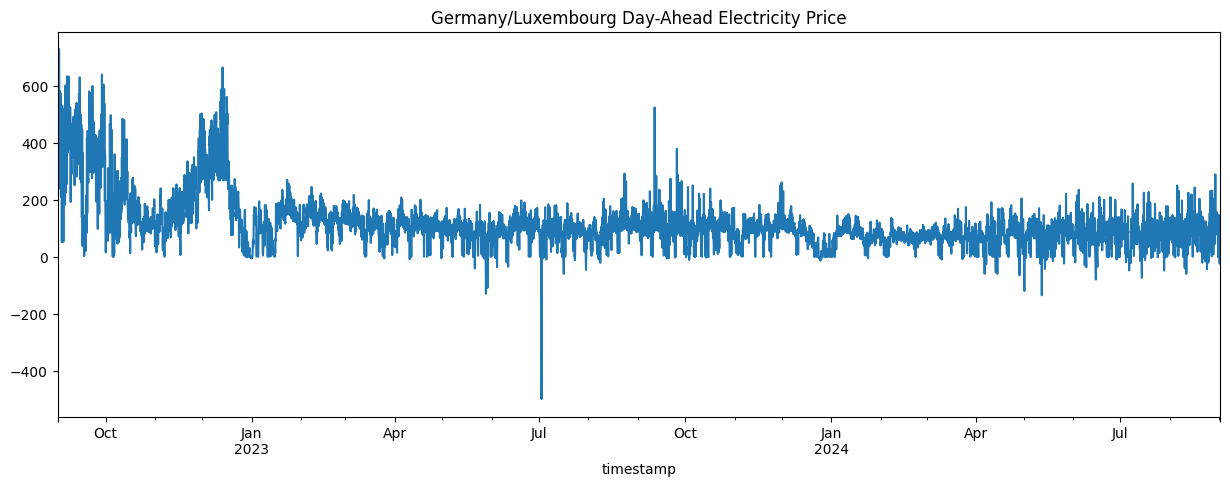

In [27]:
data["price_eur_mwh"].plot(
    figsize=(15, 5),
    title="Germany/Luxembourg Day-Ahead Electricity Price"
)

<Axes: title={'center': 'Day-Ahead Price — First Two Weeks of 2023'}, xlabel='timestamp'>

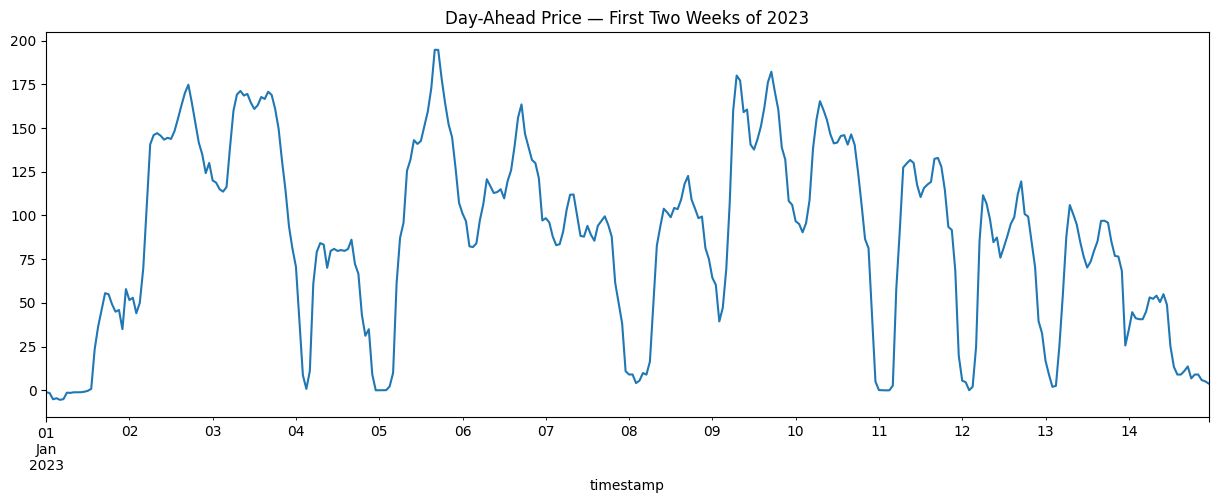

In [28]:
data.loc[
    "2023-01-01":"2023-01-14",
    "price_eur_mwh"
].plot(
    figsize=(15, 5),
    title="Day-Ahead Price — First Two Weeks of 2023"
)

<Axes: xlabel='timestamp'>

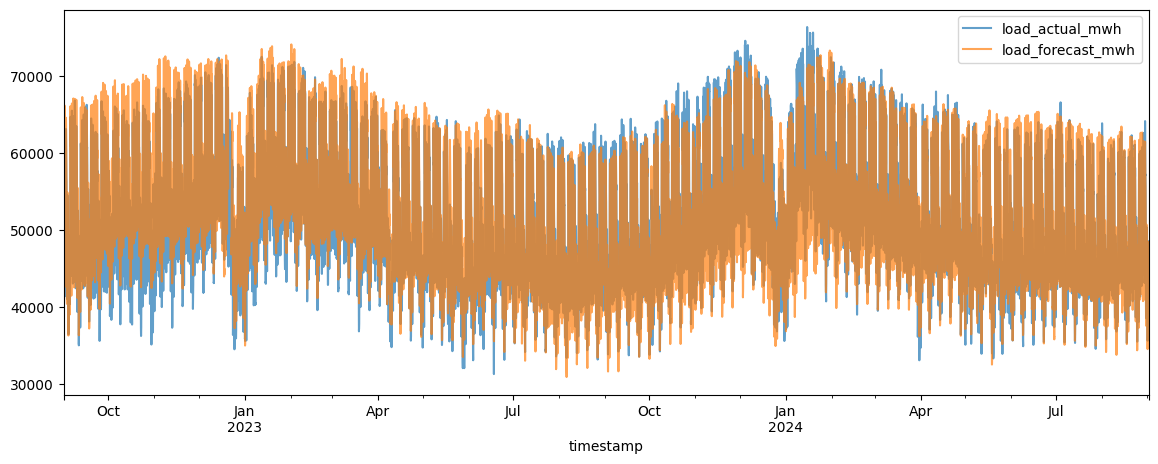

In [29]:
data[
    ["load_actual_mwh", "load_forecast_mwh"]
].plot(
    figsize=(14, 5),
    alpha=0.7
)

In [30]:
OUTPUT_PATH = Path(
    "/kaggle/working/smard_hourly_clean.parquet"
)

# Validation must succeed before anything is saved.
validate_clean_dataset(
    data,
    expected_forecast_nans=(
        EXPECTED_HISTORICAL_FORECAST_NANS
    ),
)

data.to_parquet(
    OUTPUT_PATH,
    index=True,
)

# Reload the file to ensure that its schema, values and timezone
# survive serialization.
reloaded_data = pd.read_parquet(
    OUTPUT_PATH
)

pd.testing.assert_frame_equal(
    data,
    reloaded_data,
    check_dtype=True,
    check_names=True,
)

print(
    "Saved and verified:",
    OUTPUT_PATH,
)

print(
    "Shape:",
    reloaded_data.shape,
)

print(
    "Index timezone:",
    reloaded_data.index.tz,
)

Saved and verified: /kaggle/working/smard_hourly_clean.parquet
Shape: (17568, 3)
Index timezone: UTC


In [31]:
data.to_csv(
    "/kaggle/working/smard_hourly_clean.csv"
)

In [32]:
data.head()


,price_eur_mwh,load_actual_mwh,load_forecast_mwh
timestamp,,,
2022-08-31 19:00:00+00:00,677.26,54065.25,54673.50
2022-08-31 20:00:00+00:00,563.52,50545.00,50893.75
2022-08-31 21:00:00+00:00,532.51,46610.50,47281.75
2022-08-31 22:00:00+00:00,490.77,43779.50,45334.25
2022-08-31 23:00:00+00:00,484.36,42271.75,43953.25
